# Paper Synthetic Figure

Regenerate the synthetic CO2 concentration curves used for the paper-style figure. The notebook creates the data from fixed parameters, plots the 2x3 comparison, and saves the figure to `figures/synthetic_data.png`.

## Setup

In [26]:
import contextlib
import io
import pathlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK_DIR = pathlib.Path.cwd()
if not (NOTEBOOK_DIR / "01_paper_synthetic_figure.ipynb").exists():
    NOTEBOOK_DIR = (pathlib.Path.cwd() / "notebooks" / "synthetic").resolve()

REPO_ROOT = NOTEBOOK_DIR.parents[1]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from synthetic import Generator, Simulate_Sensor
from soilgasflux_fcs import models

FIGURE_DIR = NOTEBOOK_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_PATH = FIGURE_DIR / "synthetic_data.png"

RANDOM_SEED = 25121996

## Parameter Grid

The figure compares two curve shapes across three flux intensities. `alpha` controls curvature; `c_s` is solved so each intensity reaches a fixed final concentration increase over the 180 s closure.

In [27]:
TOTAL_TIME = 180
C0 = 430.0
TIME = np.arange(TOTAL_TIME)

INTENSITY_TARGETS = {
    "low": 18.0,
    "medium": 88.0,
    "high": 178.0,
}

CURVE_ALPHA = {
    "linear": 1.0e-5,
    "convex": 3.0e-3,
}

CURVE_ORDER = ["linear", "convex"]
INTENSITY_ORDER = ["low", "medium", "high"]
SENSOR_ORDER = ["Perfect curve", "Commercial setting", "Low-cost setting"]

CHAMBER = {
    "area": np.pi * 20**2 / 4,
    "volume": np.pi * 20**2 * 20 / 4,
}

SENSOR_SETTINGS = {
    "Commercial setting": {
        "response_time": 1,
        "gas_analyzer_volume": 50,
        "sensor_accuracy": 0.1,
        "sensor_precision": 0.45,
        "pump_volume": 25,
        "pump_rate": 250,
        "additional_volume": 25,
        "with_diffusion": True,
        "with_advection": True,
    },
    "Low-cost setting": {
        "response_time": 10,
        "gas_analyzer_volume": 120,
        "sensor_accuracy": 5,
        "sensor_precision": 5,
        "pump_volume": 40,
        "pump_rate": 120,
        "additional_volume": 80,
        "with_diffusion": True,
        "with_advection": True,
    },
}

COLORS = {
    "Perfect curve": "black",
    "Commercial setting": "#f5b99f",
    "Low-cost setting": "#abc7ff",
}

LINEWIDTHS = {
    "Perfect curve": 2.2,
    "Commercial setting": 2.0,
    "Low-cost setting": 2.0,
}

In [28]:
def solve_cs(c0, alpha, target_delta, total_time):
    end_time = total_time - 1
    return c0 + target_delta / (1 - np.exp(-alpha * end_time))


def generate_perfect_config(curve_type, intensity):
    alpha = CURVE_ALPHA[curve_type]
    cs = solve_cs(C0, alpha, INTENSITY_TARGETS[intensity], TOTAL_TIME)
    generator = Generator(total_time=TOTAL_TIME, c0=C0)
    return generator.generate_base(
        alpha=alpha,
        cs=cs,
        c0=C0,
        t0=0,
        total_time=TOTAL_TIME,
        deadband=0,
        background_band=0,
        unmixed_phase=0,
        unmixed_disturbance_intensity=0,
        mixed_phase_disturbance=0,
        disturbance_intensity=0,
        disturbance_starting_point=0,
        add_noise=False,
        noise_intensity=0,
        curvature=curve_type,
        noise_type=None,
    )


def simulate_sensor_trace(config, setting, random_seed):
    if setting == "Perfect curve":
        return np.asarray(config["final_value"], dtype=float)

    hardware = SENSOR_SETTINGS[setting]
    source_dcdt = models.hm_model_dcdt(
        t0=config["t0"],
        c0=config["c_c0"],
        a=config["alpha"],
        cx=config["c_s"],
        t=TIME,
    )
    simulator = Simulate_Sensor(
        alpha=config["alpha"],
        cs=config["c_s"],
        t0=config["t0"],
        c0=config["c_c0"],
        total_time=config["total_time"],
        dt=1,
    )

    state = np.random.get_state()
    np.random.seed(random_seed)
    try:
        with contextlib.redirect_stdout(io.StringIO()):
            simulator.chamber_settings(
                area=CHAMBER["area"],
                chamber_volume=CHAMBER["volume"],
            )
            simulator.gasAnalyzer_settings(
                response_time=hardware["response_time"],
                gasAnalyzer_volume=hardware["gas_analyzer_volume"],
                sensor_accuracy=hardware["sensor_accuracy"],
                sensor_precision=hardware["sensor_precision"],
            )
            simulator.internal_pump_settings(
                pump_volume=hardware["pump_volume"],
                pump_rate=hardware["pump_rate"],
            )
            simulator.additional_settings(volume=hardware["additional_volume"])
            trace = simulator.run_simulation(
                source_ppm=source_dcdt,
                with_diffusion=hardware["with_diffusion"],
                with_advection=hardware["with_advection"],
                verbose=False,
            )
    finally:
        np.random.set_state(state)

    return np.asarray(trace, dtype=float)

## Dataset Generation

In [29]:
records = []
configs = []

for curve_index, curve_type in enumerate(CURVE_ORDER):
    for intensity_index, intensity in enumerate(INTENSITY_ORDER):
        config = generate_perfect_config(curve_type, intensity)
        configs.append({key: value for key, value in config.items() if key != "final_value"})

        for setting_index, setting in enumerate(SENSOR_ORDER):
            seed = RANDOM_SEED + 100 * curve_index + 10 * intensity_index + setting_index
            values = simulate_sensor_trace(config, setting, random_seed=seed)
            records.extend(
                {
                    "time": int(t),
                    "co2_ppm": float(co2),
                    "curve_type": curve_type,
                    "intensity": intensity,
                    "sensor_setting": setting,
                }
                for t, co2 in zip(TIME, values)
            )

dataset = pd.DataFrame.from_records(records)
parameter_table = pd.DataFrame(configs)
parameter_table

,alpha,c_s,c_c0,t0,total_time,deadband,background_band,unmixed_phase,unmixed_disturbance_intensity,mixed_phase_disturbance,disturbance_intensity,disturbance_starting_point,add_noise,noise_intensity,curvature,noise_type
0,0.00001,10494.868607,430.0,0,180,0,0,0,0,0,0,0,False,0,linear,None
1,0.00001,49636.024300,430.0,0,180,0,0,0,0,0,0,0,False,0,linear,None
2,0.00001,99960.367334,430.0,0,180,0,0,0,0,0,0,0,False,0,linear,None
3,0.00300,473.321208,430.0,0,180,0,0,0,0,0,0,0,False,0,convex,None
4,0.00300,641.792573,430.0,0,180,0,0,0,0,0,0,0,False,0,convex,None
5,0.00300,858.398614,430.0,0,180,0,0,0,0,0,0,0,False,0,convex,None


## Figure Creation

PosixPath('/Users/alexnaokiasatokobayashi/git/soilgasflux_fcs/notebooks/synthetic_create/figures/synthetic_data.png')

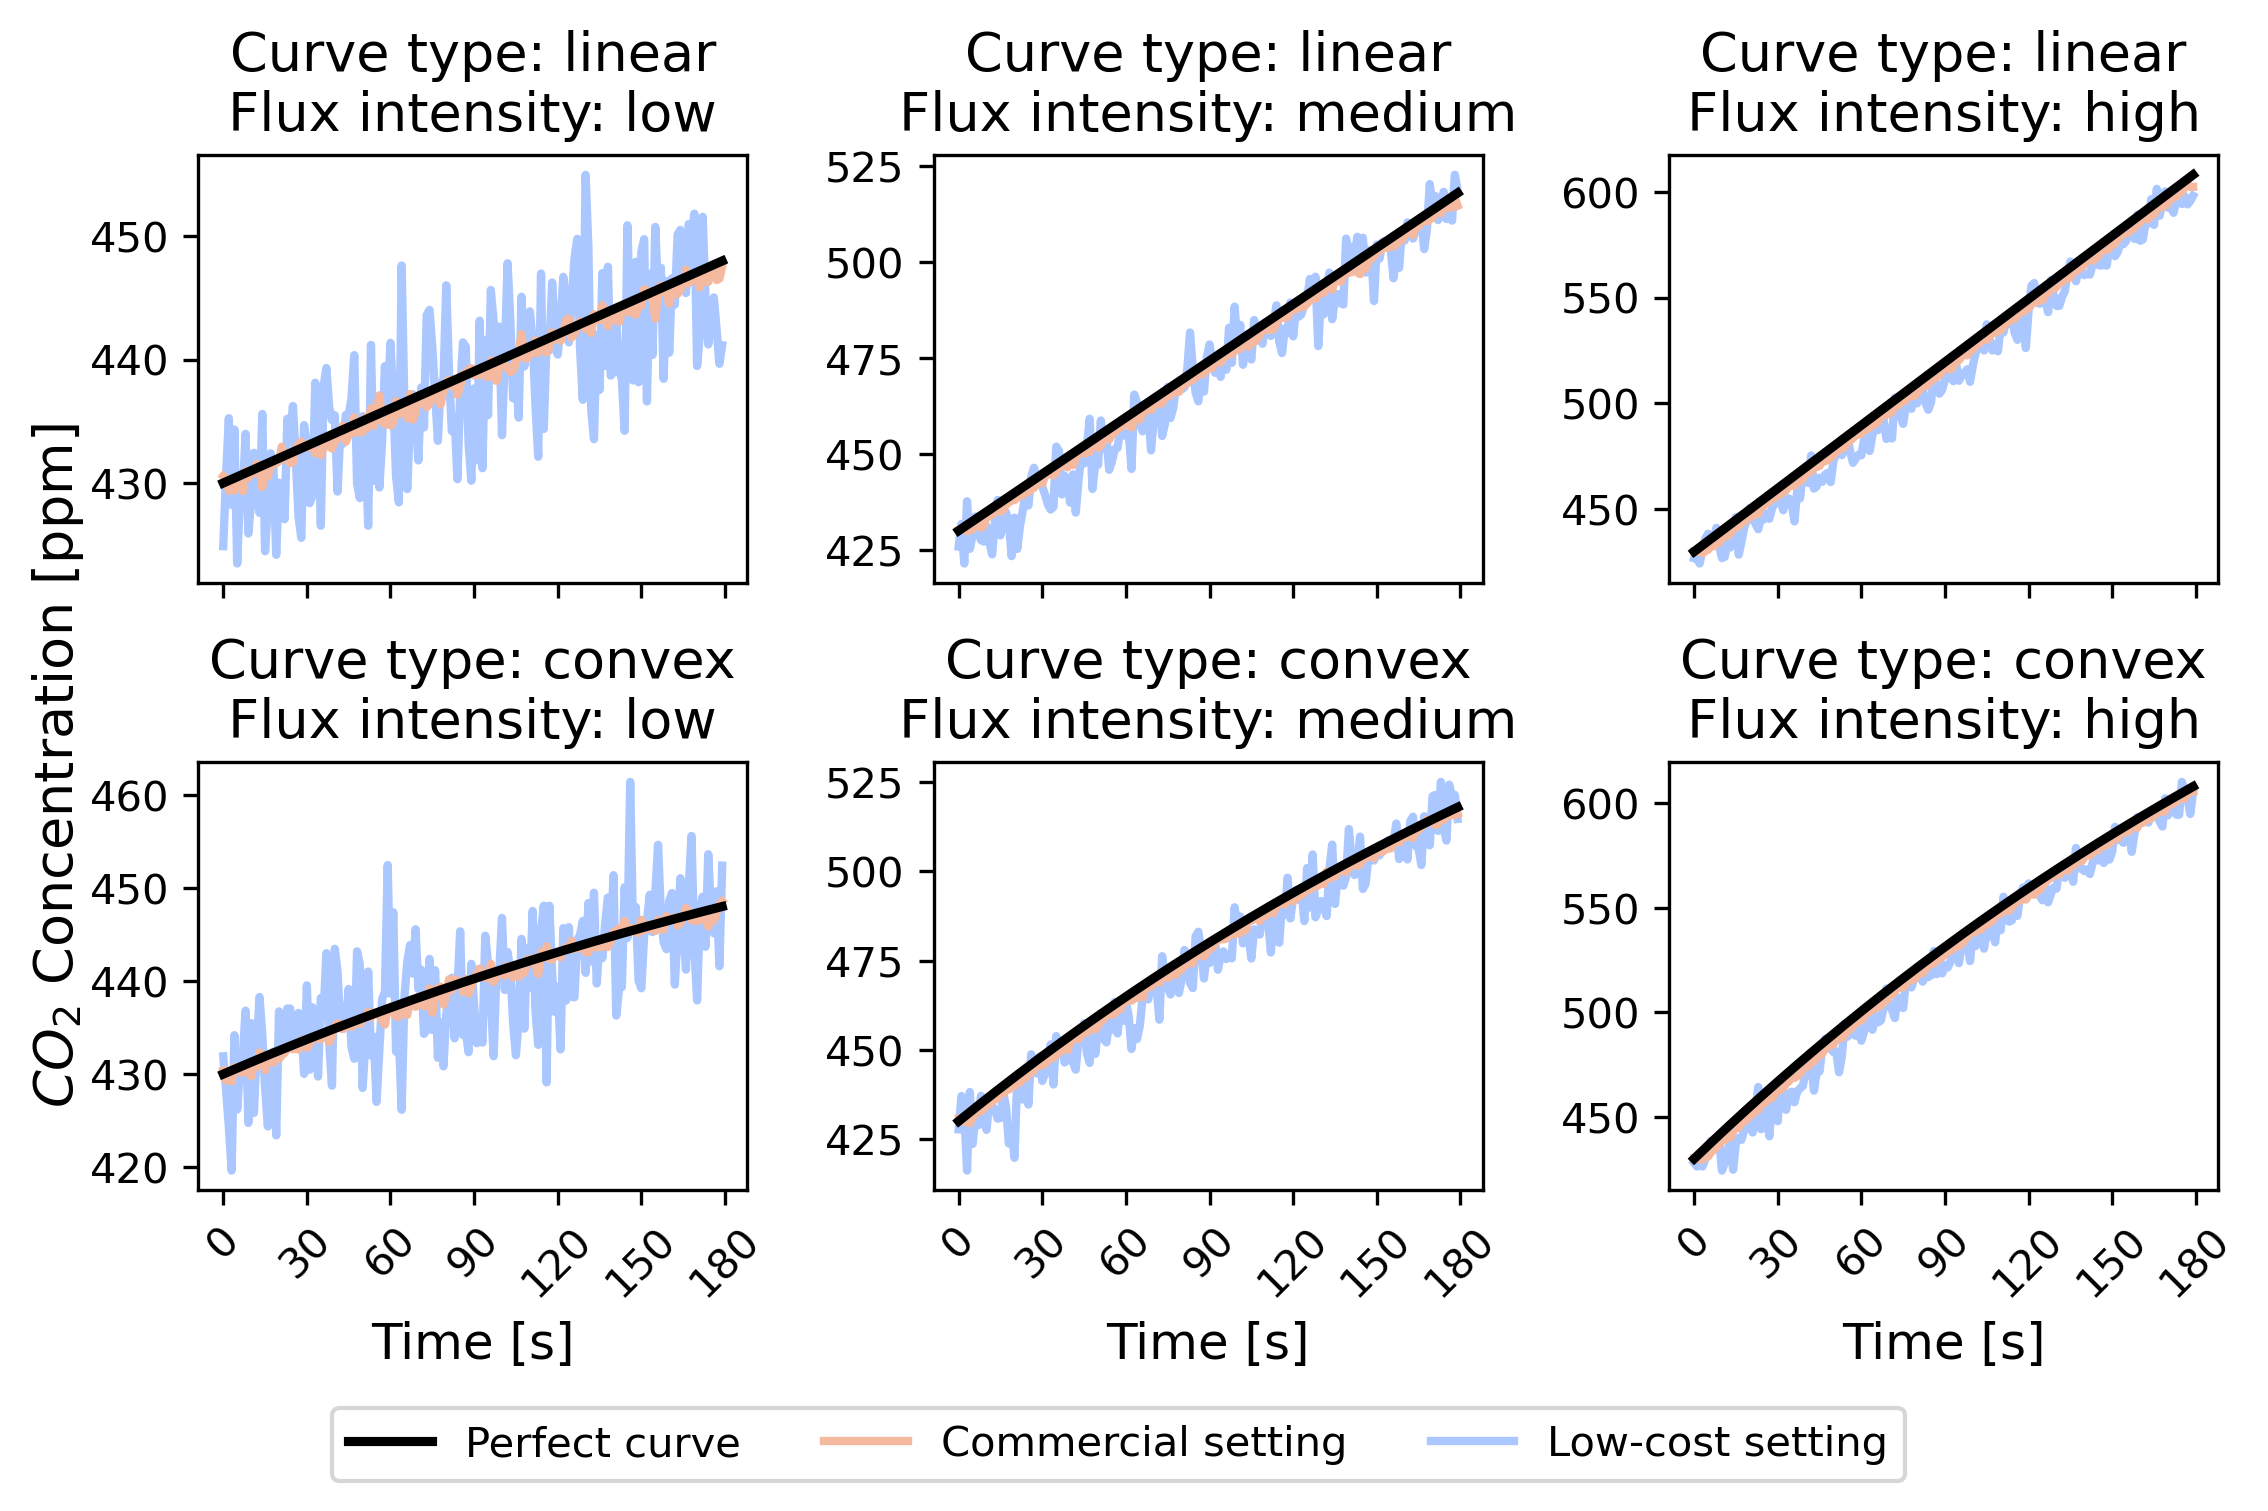

In [30]:
def plot_paper_figure(dataset, save_path):
    cm = 1 / 2.54
    fig, axes = plt.subplots(
        len(CURVE_ORDER),
        len(INTENSITY_ORDER),
        figsize=(19 * cm, 12 * cm),
        sharex=True,
        dpi=300,
    )

    plot_order = ["Low-cost setting", "Commercial setting", "Perfect curve"]

    for row, curve_type in enumerate(CURVE_ORDER):
        for col, intensity in enumerate(INTENSITY_ORDER):
            ax = axes[row, col]
            panel = dataset[
                (dataset["curve_type"] == curve_type)
                & (dataset["intensity"] == intensity)
            ]

            for setting in plot_order:
                trace = panel[panel["sensor_setting"] == setting]
                ax.plot(
                    trace["time"],
                    trace["co2_ppm"],
                    color=COLORS[setting],
                    linewidth=LINEWIDTHS[setting],
                    label=setting,
                    zorder=plot_order.index(setting) + 1,
                )

            ax.set_title(
                f"Curve type: {curve_type}\nFlux intensity: {intensity}",
                fontsize=13,
            )
            ax.set_xticks(np.arange(0, TOTAL_TIME + 1, 30))
            ax.tick_params(axis="x", labelrotation=45)
            ax.tick_params(axis="both", labelsize=10)
            for spine in ax.spines.values():
                spine.set_linewidth(0.8)

            if row == len(CURVE_ORDER) - 1:
                ax.set_xlabel("Time [s]", fontsize=12)

    fig.supylabel(r"$CO_2$ Concentration [ppm]", fontsize=13, x=0.015)

    handles_by_label = {}
    for ax in axes.ravel():
        handles, labels = ax.get_legend_handles_labels()
        handles_by_label.update(dict(zip(labels, handles)))
    fig.legend(
        [handles_by_label[label] for label in SENSOR_ORDER],
        SENSOR_ORDER,
        loc="lower center",
        ncol=3,
        frameon=True,
        bbox_to_anchor=(0.5, -0.02),
        fontsize=10,
    )
    fig.subplots_adjust(left=0.09, right=0.99, top=0.93, bottom=0.2, wspace=0.34, hspace=0.42)
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    return fig


fig = plot_paper_figure(dataset, FIGURE_PATH)
FIGURE_PATH

## Export

The figure is saved in the synthetic notebook folder. Re-run the notebook after changing the fixed parameters above to update the export.